ArcFace notebook
  train/test 사용

ResNet notebook
  train_resnet/test_resnet 사용

1 transform 정의
2 ImageFolder
3 DataLoader
4 ResNet 로드
5 학습
6 GradCAM

# train_resnet/ test_resnet 폴더 생성

In [2]:
from pathlib import Path

train_path = Path(r"C:\gachikium\dataset\train_resnet")
test_path = Path(r"C:\gachikium\dataset\test_resnet")

print("train_resnet exists:", train_path.exists())
print("test_resnet exists :", test_path.exists())

print([d.name for d in train_path.iterdir() if d.is_dir()])

train_resnet exists: True
test_resnet exists : True
[]


# split

In [3]:
import random
import shutil
from pathlib import Path

SRC_DIR   = Path(r"C:\gachikium\dataset\train_copy")     # 원본 80장
TRAIN_DIR = Path(r"C:\gachikium\dataset\train_resnet")   # ResNet용 train
TEST_DIR  = Path(r"C:\gachikium\dataset\test_resnet")    # ResNet용 test

TRAIN_RATIO = 0.8
SEED = 42
CLEAR_OUTPUT = True

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".jfif"}
random.seed(SEED)

def clear_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def list_images(folder: Path):
    return [p for p in folder.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXTS]

def safe_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def split_train_test(paths, train_ratio=0.8):
    paths = list(paths)
    random.shuffle(paths)
    n = len(paths)
    n_train = int(n * train_ratio)   # 80 -> 64
    return paths[:n_train], paths[n_train:]

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Not found: {SRC_DIR}")

if CLEAR_OUTPUT:
    clear_dir(TRAIN_DIR)
    clear_dir(TEST_DIR)

for cls_dir in sorted([d for d in SRC_DIR.iterdir() if d.is_dir()], key=lambda x: x.name):
    imgs = list_images(cls_dir)

    if len(imgs) != 80:
        print(f"[WARN] {cls_dir.name}: expected 80 but got {len(imgs)}")

    train_list, test_list = split_train_test(imgs, TRAIN_RATIO)

    for src in train_list:
        safe_copy(src, TRAIN_DIR / cls_dir.name / src.name)

    for src in test_list:
        safe_copy(src, TEST_DIR / cls_dir.name / src.name)

    print(f"{cls_dir.name}: total={len(imgs)}, train={len(train_list)}, test={len(test_list)}")

print("\nDONE")
print("train_resnet:", TRAIN_DIR)
print("test_resnet :", TEST_DIR)

강아지상: total=80, train=64, test=16
고양이상: total=80, train=64, test=16
곰상: total=80, train=64, test=16
꼬부기상: total=80, train=64, test=16
도롱뇽상: total=80, train=64, test=16
사슴상: total=80, train=64, test=16
여우상: total=80, train=64, test=16
쥐상: total=80, train=64, test=16
쿼카상: total=80, train=64, test=16
토끼상: total=80, train=64, test=16

DONE
train_resnet: C:\gachikium\dataset\train_resnet
test_resnet : C:\gachikium\dataset\test_resnet


In [6]:
print([d.name for d in train_path.iterdir() if d.is_dir()])

['강아지상', '고양이상', '곰상', '꼬부기상', '도롱뇽상', '사슴상', '여우상', '쥐상', '쿼카상', '토끼상']


# 얼굴 검출기

In [55]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop

face_app = FaceAnalysis(name="buffalo_l")
face_app.prepare(ctx_id=0, det_size=(640, 640))   # GPU면 0, CPU면 -1

def imread_unicode(path: str):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def detect_and_crop_face(img_bgr, min_face_ratio=0.05):
    faces = face_app.get(img_bgr)
    if not faces:
        return None, None

    face = max(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
    )

    x1, y1, x2, y2 = face.bbox
    face_area = (x2 - x1) * (y2 - y1)
    img_area = img_bgr.shape[0] * img_bgr.shape[1]

    if face_area / img_area < min_face_ratio:
        return None, None

    if getattr(face, "kps", None) is not None:
        cropped = norm_crop(img_bgr, face.kps)
        cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        return Image.fromarray(cropped), face.bbox

    return None, None


import torch

def predict_animal_face_with_gate(img_path, model, transform, class_names, device):
    """
    1단계: 얼굴 검출
    2단계: 얼굴 있으면 분류
    """

    img_bgr = imread_unicode(img_path)
    if img_bgr is None:
        return {
            "status": "error",
            "message": "이미지를 읽을 수 없습니다."
        }

    # 1단계: 얼굴 검출
    face_pil, bbox = detect_and_crop_face(img_bgr)

    if face_pil is None:
        return {
            "status": "no_face",
            "message": "얼굴이 검출되지 않아 분류하지 않았습니다."
        }

    # 2단계: 얼굴 분류
    input_tensor = transform(face_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    return {
        "status": "ok",
        "pred_class": class_names[pred_idx],
        "confidence": float(pred_prob),
        "bbox": bbox.tolist() if bbox is not None else None
    }

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

In [56]:
result = predict_animal_face_with_gate(
    img_path=r"C:\gachikium\Image_81.png",
    model=model,
    transform=transform_test,
    class_names=class_names,
    device=device
)

print(result)

{'status': 'no_face', 'message': '얼굴이 검출되지 않아 분류하지 않았습니다.'}


# Transform

In [ ]:
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

face_transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset / DataLoader

In [7]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(
    r"C:\gachikium\dataset\train_resnet", 
    transform=transform_train
    )

test_dataset  = ImageFolder(
    r"C:\gachikium\dataset\test_resnet", 
    transform=transform_test
    )

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(class_names)
print("train size:", len(train_dataset))
print("test size :", len(test_dataset))

['강아지상', '고양이상', '곰상', '꼬부기상', '도롱뇽상', '사슴상', '여우상', '쥐상', '쿼카상', '토끼상']
train size: 640
test size : 160


# Resnet 학습

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(class_names)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 41.3MB/s]


Epoch 1/10 | train_loss=1.3061, train_acc=0.5766 | test_loss=0.7976, test_acc=0.7750
Epoch 2/10 | train_loss=0.3792, train_acc=0.9344 | test_loss=0.4369, test_acc=0.8812
Epoch 3/10 | train_loss=0.1374, train_acc=0.9812 | test_loss=0.3230, test_acc=0.9375
Epoch 4/10 | train_loss=0.0694, train_acc=0.9969 | test_loss=0.2717, test_acc=0.9375
Epoch 5/10 | train_loss=0.0323, train_acc=1.0000 | test_loss=0.2700, test_acc=0.9437
Epoch 6/10 | train_loss=0.0232, train_acc=0.9969 | test_loss=0.2591, test_acc=0.9313
Epoch 7/10 | train_loss=0.0158, train_acc=1.0000 | test_loss=0.2521, test_acc=0.9375
Epoch 8/10 | train_loss=0.0121, train_acc=1.0000 | test_loss=0.2480, test_acc=0.9500
Epoch 9/10 | train_loss=0.0096, train_acc=1.0000 | test_loss=0.2464, test_acc=0.9437
Epoch 10/10 | train_loss=0.0071, train_acc=1.0000 | test_loss=0.2419, test_acc=0.9375


# Best model 저장

In [ ]:
# import torchvision.models as models
# import torch.nn as nn

# model = models.resnet18(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, 10)

# model = model.to(device)

# torch.save(model.state_dict(), "animalface_resnet18_gradcam.pth")
# print("saved")

saved


In [41]:
best_acc = 0

for epoch in range(num_epochs):

    # train
    # test

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved:", best_acc)

Best model saved: 0.9375


In [47]:
torch.save(model.state_dict(), "animalface_resnet18_gradcam.pth")
print("saved")

saved


In [48]:
import os
os.listdir()

['.python-version',
 'animal.ipynb',
 'animal0.ipynb',
 'animalface_resnet18_gradcam.pth',
 'Animal_v1_arcface.ipynb',
 'Animal_v2_resnet.ipynb',
 'best_model.pth',
 'clean_dataset.py',
 'fix_crops.py',
 'fix_crops2.py',
 'main.py',
 'python',
 'README.md',
 'rename_file.py',
 'rename_images.py',
 'resnet_animalface.pth',
 'restore_crops.py',
 'split_face.py',
 'test.ipynb']

# 예측값/정답 수집

In [10]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("test acc:", accuracy_score(all_labels, all_preds))

test acc: 0.9375


In [11]:
print("=== classification_report ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

=== classification_report ===
              precision    recall  f1-score   support

        강아지상       0.87      0.81      0.84        16
        고양이상       0.94      1.00      0.97        16
          곰상       1.00      1.00      1.00        16
        꼬부기상       0.82      0.88      0.85        16
        도롱뇽상       1.00      1.00      1.00        16
         사슴상       1.00      0.88      0.93        16
         여우상       0.94      0.94      0.94        16
          쥐상       0.88      0.94      0.91        16
         쿼카상       1.00      1.00      1.00        16
         토끼상       0.94      0.94      0.94        16

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



In [13]:
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)

print("=== confusion_matrix ===")
print(cm)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

=== confusion_matrix ===
[[13  0  0  1  0  0  1  1  0  0]
 [ 0 16  0  0  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0  0  0]
 [ 1  0  0 14  0  0  0  0  0  1]
 [ 0  0  0  0 16  0  0  0  0  0]
 [ 1  0  0  0  0 14  0  1  0  0]
 [ 0  1  0  0  0  0 15  0  0  0]
 [ 0  0  0  1  0  0  0 15  0  0]
 [ 0  0  0  0  0  0  0  0 16  0]
 [ 0  0  0  1  0  0  0  0  0 15]]


,강아지상,고양이상,곰상,꼬부기상,도롱뇽상,사슴상,여우상,쥐상,쿼카상,토끼상
강아지상,13,0,0,1,0,0,1,1,0,0
고양이상,0,16,0,0,0,0,0,0,0,0
곰상,0,0,16,0,0,0,0,0,0,0
꼬부기상,1,0,0,14,0,0,0,0,0,1
도롱뇽상,0,0,0,0,16,0,0,0,0,0
사슴상,1,0,0,0,0,14,0,1,0,0
여우상,0,1,0,0,0,0,15,0,0,0
쥐상,0,0,0,1,0,0,0,15,0,0
쿼카상,0,0,0,0,0,0,0,0,16,0
토끼상,0,0,0,1,0,0,0,0,0,15


In [ ]:
torch.save(model.state_dict(), "animalface_resnet18_gradcam.pth")

# grad CAM

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [17]:
gradcam_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
from pathlib import Path
import random

folder = Path(r"C:\gachikium\dataset\train_resnet\강아지상")

img_path = random.choice(list(folder.glob("*.png")))

print(img_path)


C:\gachikium\dataset\train_resnet\강아지상\Image_47.png


In [ ]:
img_path = r"C:\gachikium\dataset\train_resnet\강아지상\Image_81.png"

In [29]:
from PIL import Image

img = Image.open(img_path).convert("RGB")

# 시각화용 원본
rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0

# 모델 입력용
input_tensor = gradcam_transform(img).unsqueeze(0).to(device)

model.eval()

# 예측 클래스 확인
with torch.no_grad():
    output = model(input_tensor)
    pred_idx = output.argmax(dim=1).item()

print("predicted class:", class_names[pred_idx])

predicted class: 강아지상


In [30]:
from pytorch_grad_cam import GradCAM
print("GradCAM import success")

GradCAM import success


1) target layer 지정 마지막 conv block

In [31]:
target_layers = [model.layer4[-1]]

2. Grad-CAM 객체 만들기

In [32]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=target_layers)

3. 현재 예측한 클래스 기준으로 heatmap 계산

In [33]:
targets = [ClassifierOutputTarget(pred_idx)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

4) 원본 이미지 위에 덮어서 시각화

In [34]:
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

5) 화면에 출력

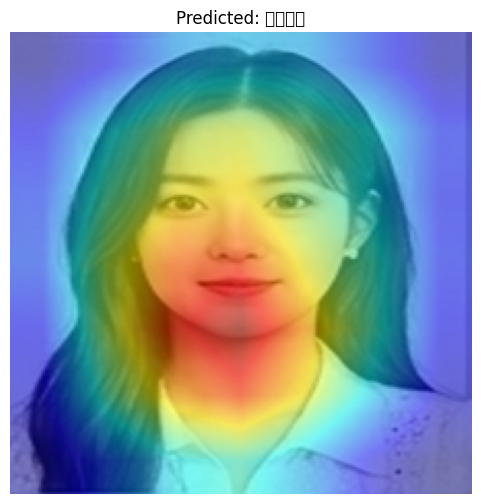

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(visualization)
plt.title(f"Predicted: {class_names[pred_idx]}")
plt.axis("off")
plt.show()

sample 데이터 dictionary 형태로 정리해둠

In [36]:
samples = {
    "강아지상": [
        r"C:\gachikium\dataset\test_resnet\강아지상\Image_01.png",
        r"C:\gachikium\dataset\test_resnet\강아지상\Image_05.png",
        r"C:\gachikium\dataset\test_resnet\강아지상\Image_09.png",
    ],
    "여우상": [
        r"C:\gachikium\dataset\test_resnet\여우상\Image_02.png",
        r"C:\gachikium\dataset\test_resnet\여우상\Image_07.png",
        r"C:\gachikium\dataset\test_resnet\여우상\Image_11.png",
    ],
    "꼬부기상": [
        r"C:\gachikium\dataset\test_resnet\꼬부기상\Image_03.png",
        r"C:\gachikium\dataset\test_resnet\꼬부기상\Image_08.png",
        r"C:\gachikium\dataset\test_resnet\꼬부기상\Image_12.png",
    ],
    "도롱뇽상": [
        r"C:\gachikium\dataset\test_resnet\도롱뇽상\Image_04.png",
        r"C:\gachikium\dataset\test_resnet\도롱뇽상\Image_10.png",
        r"C:\gachikium\dataset\test_resnet\도롱뇽상\Image_13.png",
    ],
}

같은 이미지에 대해 정답/예측 코드 둘 다 보기. 

C:\Users\user\AppData\Local\Temp\ipykernel_36568\2213848455.py:29: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36568\2213848455.py:29: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36568\2213848455.py:29: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36568\2213848455.py:29: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


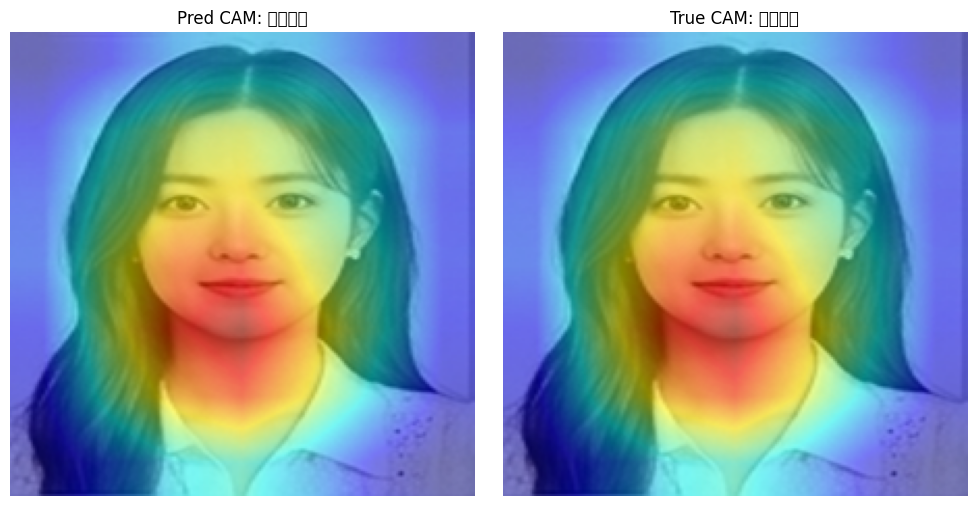

In [ ]:
true_class_name = "강아지상"
true_idx = class_names.index(true_class_name)

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 예측 클래스 CAM
pred_targets = [ClassifierOutputTarget(pred_idx)]
pred_cam = cam(input_tensor=input_tensor, targets=pred_targets)[0]
pred_vis = show_cam_on_image(rgb_img, pred_cam, use_rgb=True)

# 정답 클래스 CAM
true_targets = [ClassifierOutputTarget(true_idx)]
true_cam = cam(input_tensor=input_tensor, targets=true_targets)[0]
true_vis = show_cam_on_image(rgb_img, true_cam, use_rgb=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_vis)
plt.title(f"Pred CAM: {class_names[pred_idx]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(true_vis)
plt.title(f"True CAM: {class_names[true_idx]}")
plt.axis("off")

plt.tight_layout()
plt.show()

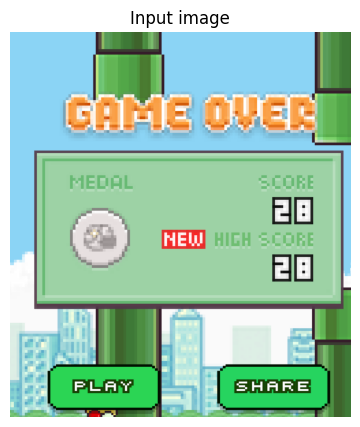

Predicted class: 쥐상
Confidence: 0.968


In [54]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 테스트할 이미지 경로
img_path = r"C:\gachikium\Image_81.png"   # <- 네 파일 경로로 바꿔

# 이미지 열기
img = Image.open(img_path).convert("RGB")

# 시각화
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()

# 모델 입력으로 변환
input_tensor = transform_test(img).unsqueeze(0).to(device)

# 예측
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.nn.functional.softmax(outputs, dim=1)

    conf, predicted = torch.max(probs,1)

    result_idx = predicted.item()
    probability = conf.item()*100


print("Predicted class:", class_names[pred_idx])
print("Confidence:", round(pred_prob, 4))



# with torch.no_grad():
#     output = model(input_tensor)
#     probs = torch.softmax(output, dim=1)
#     pred_idx = probs.argmax(dim=1).item()
#     pred_prob = probs[0, pred_idx].item()

# print("Predicted class:", class_names[pred_idx])
# print("Confidence:", round(pred_prob, 4))

In [50]:
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)

topk = torch.topk(probs, k=3, dim=1)

top_indices = topk.indices[0].cpu().numpy()
top_values = topk.values[0].cpu().numpy()

print("Top-3 predictions")
for idx, val in zip(top_indices, top_values):
    print(f"{class_names[idx]}: {val:.4f}")

Top-3 predictions
쥐상: 0.9680
강아지상: 0.0201
여우상: 0.0024


c:\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51536 (\N{HANGUL SYLLABLE JWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


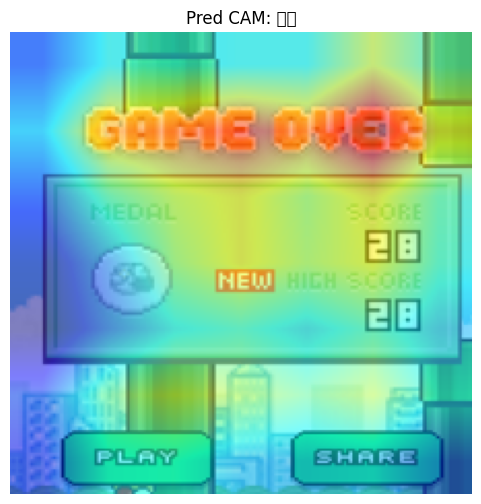

In [51]:
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 시각화용 원본
rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

targets = [ClassifierOutputTarget(pred_idx)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title(f"Pred CAM: {class_names[pred_idx]}")
plt.axis("off")
plt.show()

1) 얼굴 검출기 준비